# Phase 13 — Stress Testing

**Question**: Would the strategy survive?

Test against 10 historical crises:
- **GFC 2008** — Lehman collapse, −57% SPY
- **GFC Reversal 2009** — V-shaped recovery, momentum crashes
- **Flash Crash 2010** — Algorithmic event
- **Euro Crisis 2011** — European sovereign debt
- **Oil Collapse 2014-16** — Commodity bust (strategy's own worst period)
- **China Scare 2015** — EM sell-off
- **COVID Crash 2020** — Fastest bear market in history
- **Commodity Boom 2020-22** — Post-COVID supercycle
- **Inflation Bear 2022** — Bonds AND equities both fell
- **AI Bull 2023-24** — Narrow Mag-7 driven rally

Verdict per scenario: THRIVED ★★ / SURVIVED ✓ / PROTECTED ↓↑ / LAGGED ~ / FAILED ✗

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from src.data import load_prices, compute_returns
from src.stress_testing import (
    run_stress_testing, STRESS_EVENTS, STRESS_COLOR, ASSET_CLASSES, var_cvar
)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


In [2]:
prices  = load_prices(directory='../data/processed')
returns = compute_returns(prices)

res         = run_stress_testing(prices, returns, proc_dir='../data/processed')
stress_df   = res['stress_table']
details     = res['details']
tail_risk   = res['tail_risk']
hrp_ret     = res['hrp_ret']
spy_ret     = res['spy_ret']
weights_df  = res['weights_df']


  STRESS TESTING — Momentum → Top-5 → 200DMA → HRP
  Scenario                 N     HRP%     SPY%   Excess   HRP DD   SPY DD    Eq%    Bd%    Cm%  Verdict
  ────────────────────── ───  ───────  ───────  ───────  ───────  ───────  ─────  ─────  ─────  ──────────────
  GFC Crash               18   +19.2%   -48.2%   +67.4%    -8.2%   -50.8%    10%    58%    31%  THRIVED ★★  [+140% prot]
  GFC Reversal            10    +3.3%   +54.2%   -51.0%    -7.7%    -1.9%    30%    50%    15%  LAGGED ~
  Flash Crash 2010         2    -3.5%   -12.7%    +9.2%    +0.0%    -5.2%    28%    44%    21%  PROTECTED ↓↑  [+73% prot]
  Euro Crisis 2011         4    +5.0%    -4.4%    +9.4%    -0.1%   -12.1%     7%    63%    27%  SURVIVED ✓  [+214% prot]
  Oil Collapse            19    -4.5%    +2.1%    -6.6%   -12.3%    -8.5%    29%    60%     0%  FAILED ✗
  China Scare 2015         2    +0.1%    -8.5%    +8.6%    -0.1%    -2.6%     0%   100%     0%  SURVIVED ✓  [+101% prot]
  COVID Crash              3    -1.5% 

## Scenario Summary — All 10 Stress Events

Color-coded: green = outperform, red = underperform.

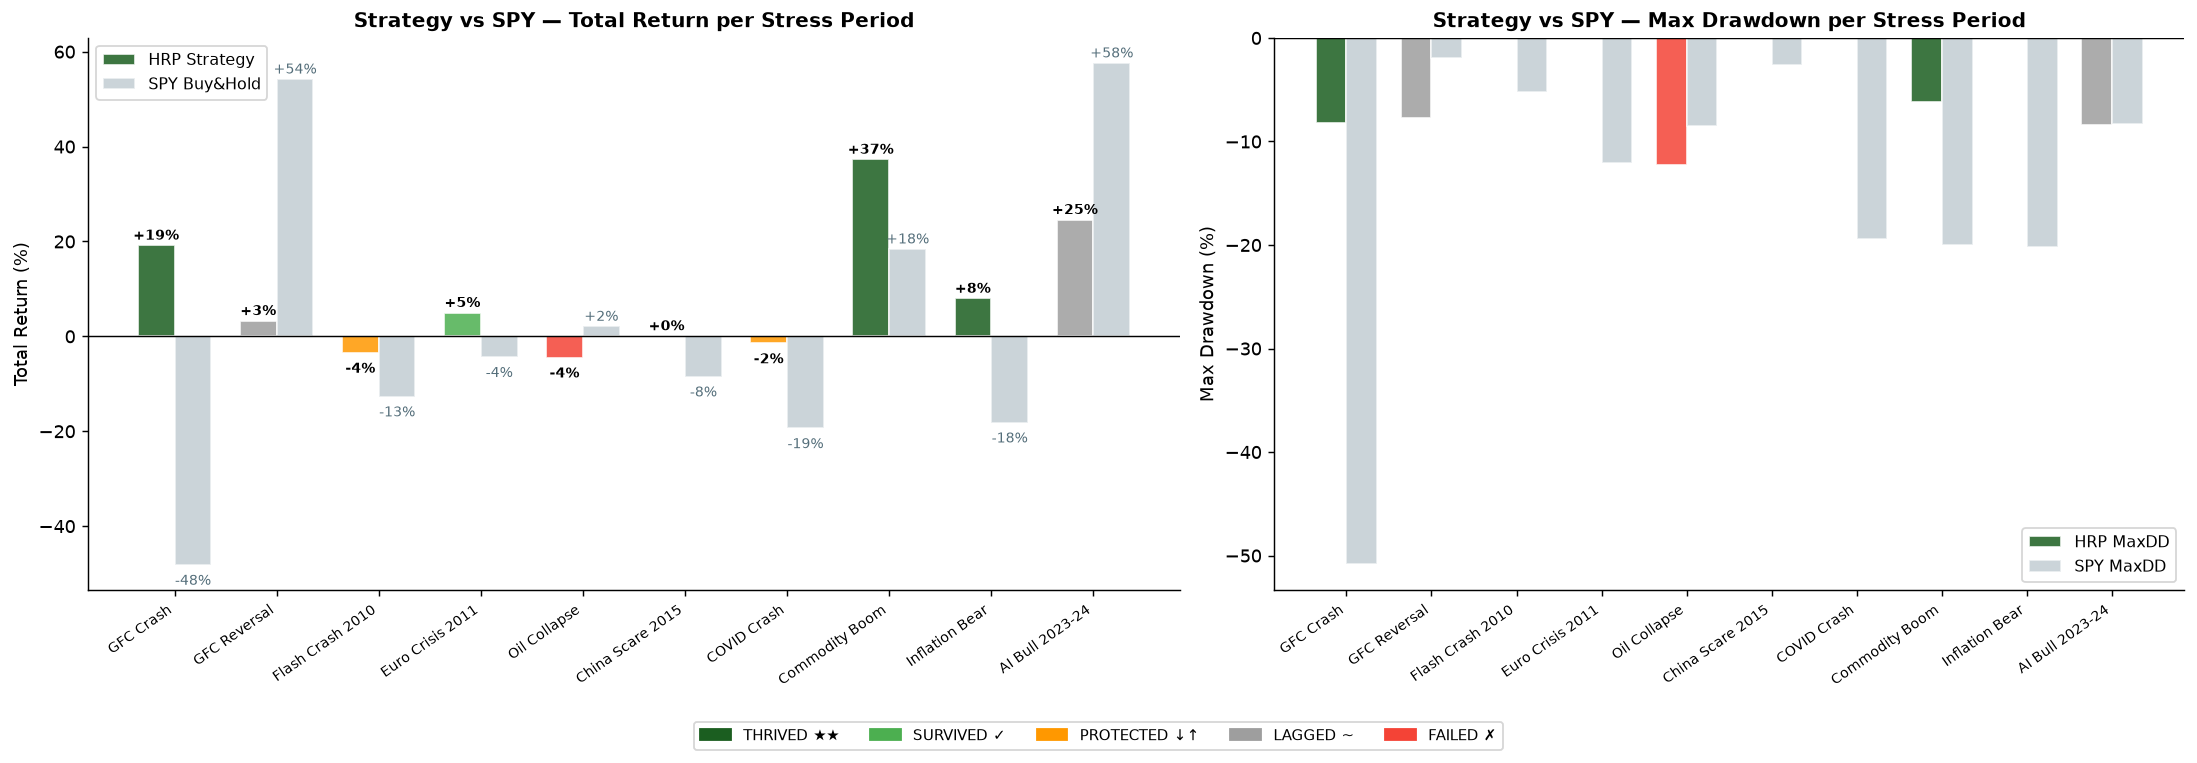

In [3]:
VERDICT_ICON = {
    'THRIVED ★★': '★★  THRIVED',
    'SURVIVED ✓':  '✓   SURVIVED',
    'PROTECTED ↓↑': '↓↑  PROTECTED',
    'LAGGED ~':    '~   LAGGED',
    'FAILED ✗':   '✗   FAILED',
}
VERDICT_COLOR = {
    'THRIVED ★★':   '#1B5E20',
    'SURVIVED ✓':   '#4CAF50',
    'PROTECTED ↓↑': '#FF9800',
    'LAGGED ~':     '#9E9E9E',
    'FAILED ✗':    '#F44336',
}

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={'width_ratios': [1.2, 1]})

# ── Left: HRP vs SPY total return per scenario ──
ax = axes[0]
scenarios = stress_df.index.tolist()
x = np.arange(len(scenarios))
w = 0.36

hrp_vals = stress_df['HRP %'].values
spy_vals = stress_df['SPY %'].values
verdicts = stress_df['Verdict'].values
vc = [VERDICT_COLOR.get(v, '#9E9E9E') for v in verdicts]

b1 = ax.bar(x - w/2, hrp_vals, w, label='HRP Strategy', color=vc, alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, spy_vals, w, label='SPY Buy&Hold', color='#B0BEC5', alpha=0.65, edgecolor='white')

for b, v in zip(b1, hrp_vals):
    ax.text(b.get_x()+b.get_width()/2, v + (0.5 if v>=0 else -2),
            f'{v:+.0f}%', ha='center', va='bottom' if v>=0 else 'top', fontsize=7.5, fontweight='bold')
for b, v in zip(b2, spy_vals):
    ax.text(b.get_x()+b.get_width()/2, v + (0.5 if v>=0 else -2),
            f'{v:+.0f}%', ha='center', va='bottom' if v>=0 else 'top', fontsize=7.5, color='#546E7A')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(scenarios, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Total Return (%)')
ax.set_title('Strategy vs SPY — Total Return per Stress Period', fontweight='bold')
ax.legend(fontsize=9)

# ── Right: Max drawdown comparison ──
ax = axes[1]
hrp_dd = stress_df['HRP MaxDD %'].values
spy_dd = stress_df['SPY MaxDD %'].values

b3 = ax.bar(x - w/2, hrp_dd, w, label='HRP MaxDD', color=vc, alpha=0.85, edgecolor='white')
b4 = ax.bar(x + w/2, spy_dd, w, label='SPY MaxDD', color='#B0BEC5', alpha=0.65, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(scenarios, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Max Drawdown (%)')
ax.set_title('Strategy vs SPY — Max Drawdown per Stress Period', fontweight='bold')
ax.legend(fontsize=9)

# Verdict legend
patches = [mpatches.Patch(color=c, label=k) for k, c in VERDICT_COLOR.items()]
fig.legend(handles=patches, loc='upper center', ncol=5, fontsize=8.5, frameon=True,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.show()

## Portfolio Composition During Each Stress Event

What did the strategy actually hold? This explains the performance.

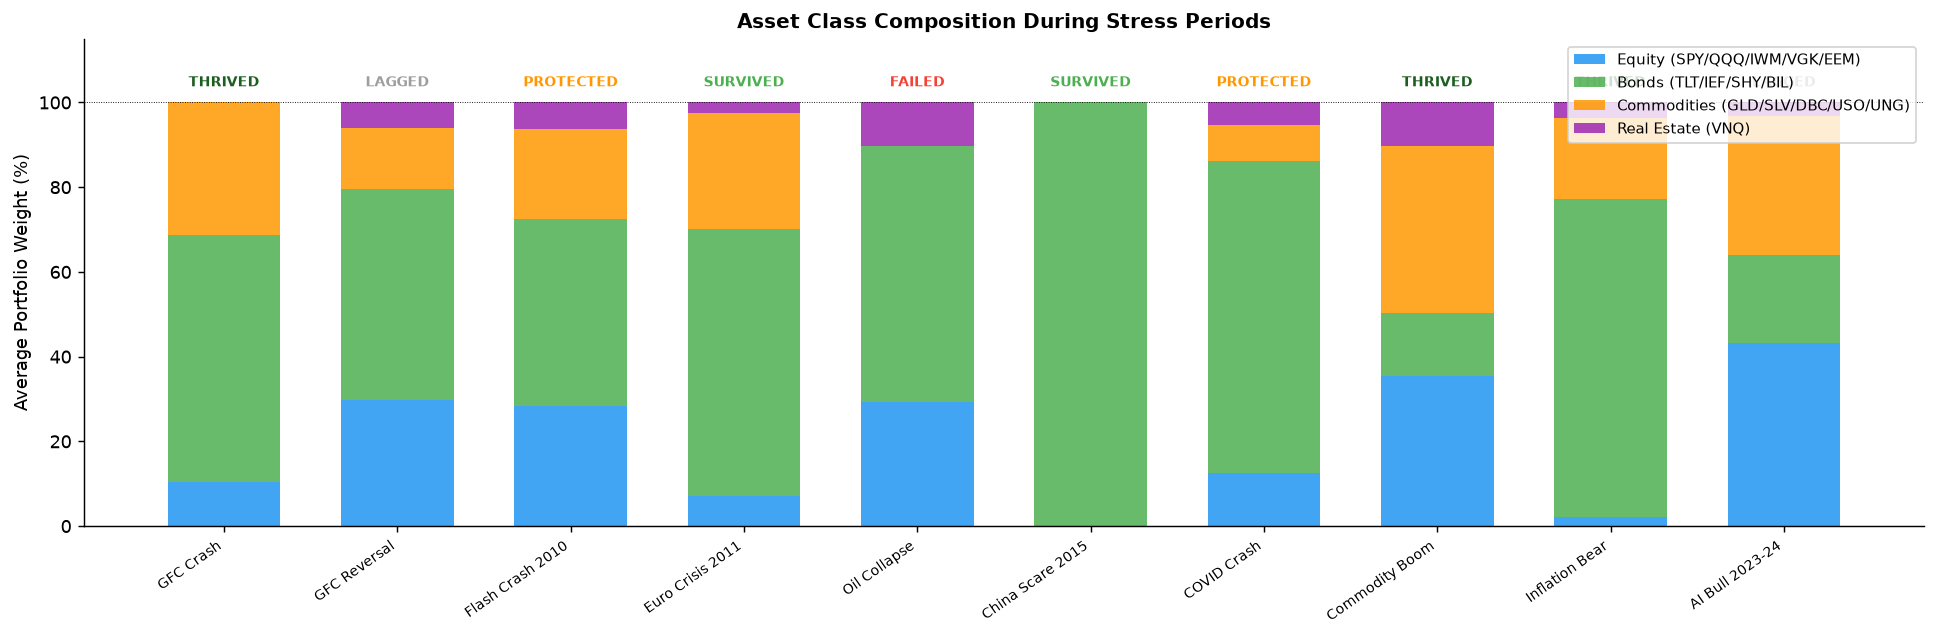

Key insight: The 200DMA filter and momentum rotation drive these allocations automatically.
GFC Crash → 58% bonds, 31% commodities (GLD fled to safety)
COVID Crash → 74% bonds, only 12% equity
Inflation Bear → 75% bonds (BIL/SHY, short-duration) + 19% commodities
Oil Collapse → 60% bonds held, but US equities (SPY) also held = dragged performance


In [4]:
fig, ax = plt.subplots(figsize=(15, 5))

scenarios   = [d['name'] for d in details]
equity_wts  = [d['class_equity'] * 100 for d in details]
bond_wts    = [d['class_bonds'] * 100 for d in details]
cmdty_wts   = [d['class_commodities'] * 100 for d in details]
re_wts      = [(1 - d['class_equity'] - d['class_bonds'] - d['class_commodities']) * 100 for d in details]
re_wts      = [max(0, r) for r in re_wts]

x = np.arange(len(scenarios))
w = 0.65

p1 = ax.bar(x, equity_wts, w, label='Equity (SPY/QQQ/IWM/VGK/EEM)', color='#2196F3', alpha=0.85)
p2 = ax.bar(x, bond_wts,   w, bottom=equity_wts, label='Bonds (TLT/IEF/SHY/BIL)', color='#4CAF50', alpha=0.85)
p3 = ax.bar(x, cmdty_wts,  w,
            bottom=[e+b for e, b in zip(equity_wts, bond_wts)],
            label='Commodities (GLD/SLV/DBC/USO/UNG)', color='#FF9800', alpha=0.85)
p4 = ax.bar(x, re_wts, w,
            bottom=[e+b+c for e, b, c in zip(equity_wts, bond_wts, cmdty_wts)],
            label='Real Estate (VNQ)', color='#9C27B0', alpha=0.85)

# Verdict badges above bars
for i, d in enumerate(details):
    v = d['verdict']
    c = VERDICT_COLOR.get(v, '#9E9E9E')
    ax.text(i, 103, v.split(' ')[0], ha='center', va='bottom', fontsize=8, color=c, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(scenarios, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Average Portfolio Weight (%)')
ax.set_ylim(0, 115)
ax.set_title('Asset Class Composition During Stress Periods', fontweight='bold')
ax.legend(loc='upper right', fontsize=8.5)
ax.axhline(100, color='black', linewidth=0.5, linestyle=':')

plt.tight_layout()
plt.show()

print('Key insight: The 200DMA filter and momentum rotation drive these allocations automatically.')
print('GFC Crash → 58% bonds, 31% commodities (GLD fled to safety)')
print('COVID Crash → 74% bonds, only 12% equity')
print('Inflation Bear → 75% bonds (BIL/SHY, short-duration) + 19% commodities')
print('Oil Collapse → 60% bonds held, but US equities (SPY) also held = dragged performance')

## Equity Curves During Each Stress Event

Normalized to 100 at start of period. Strategy (blue) vs SPY (gray).

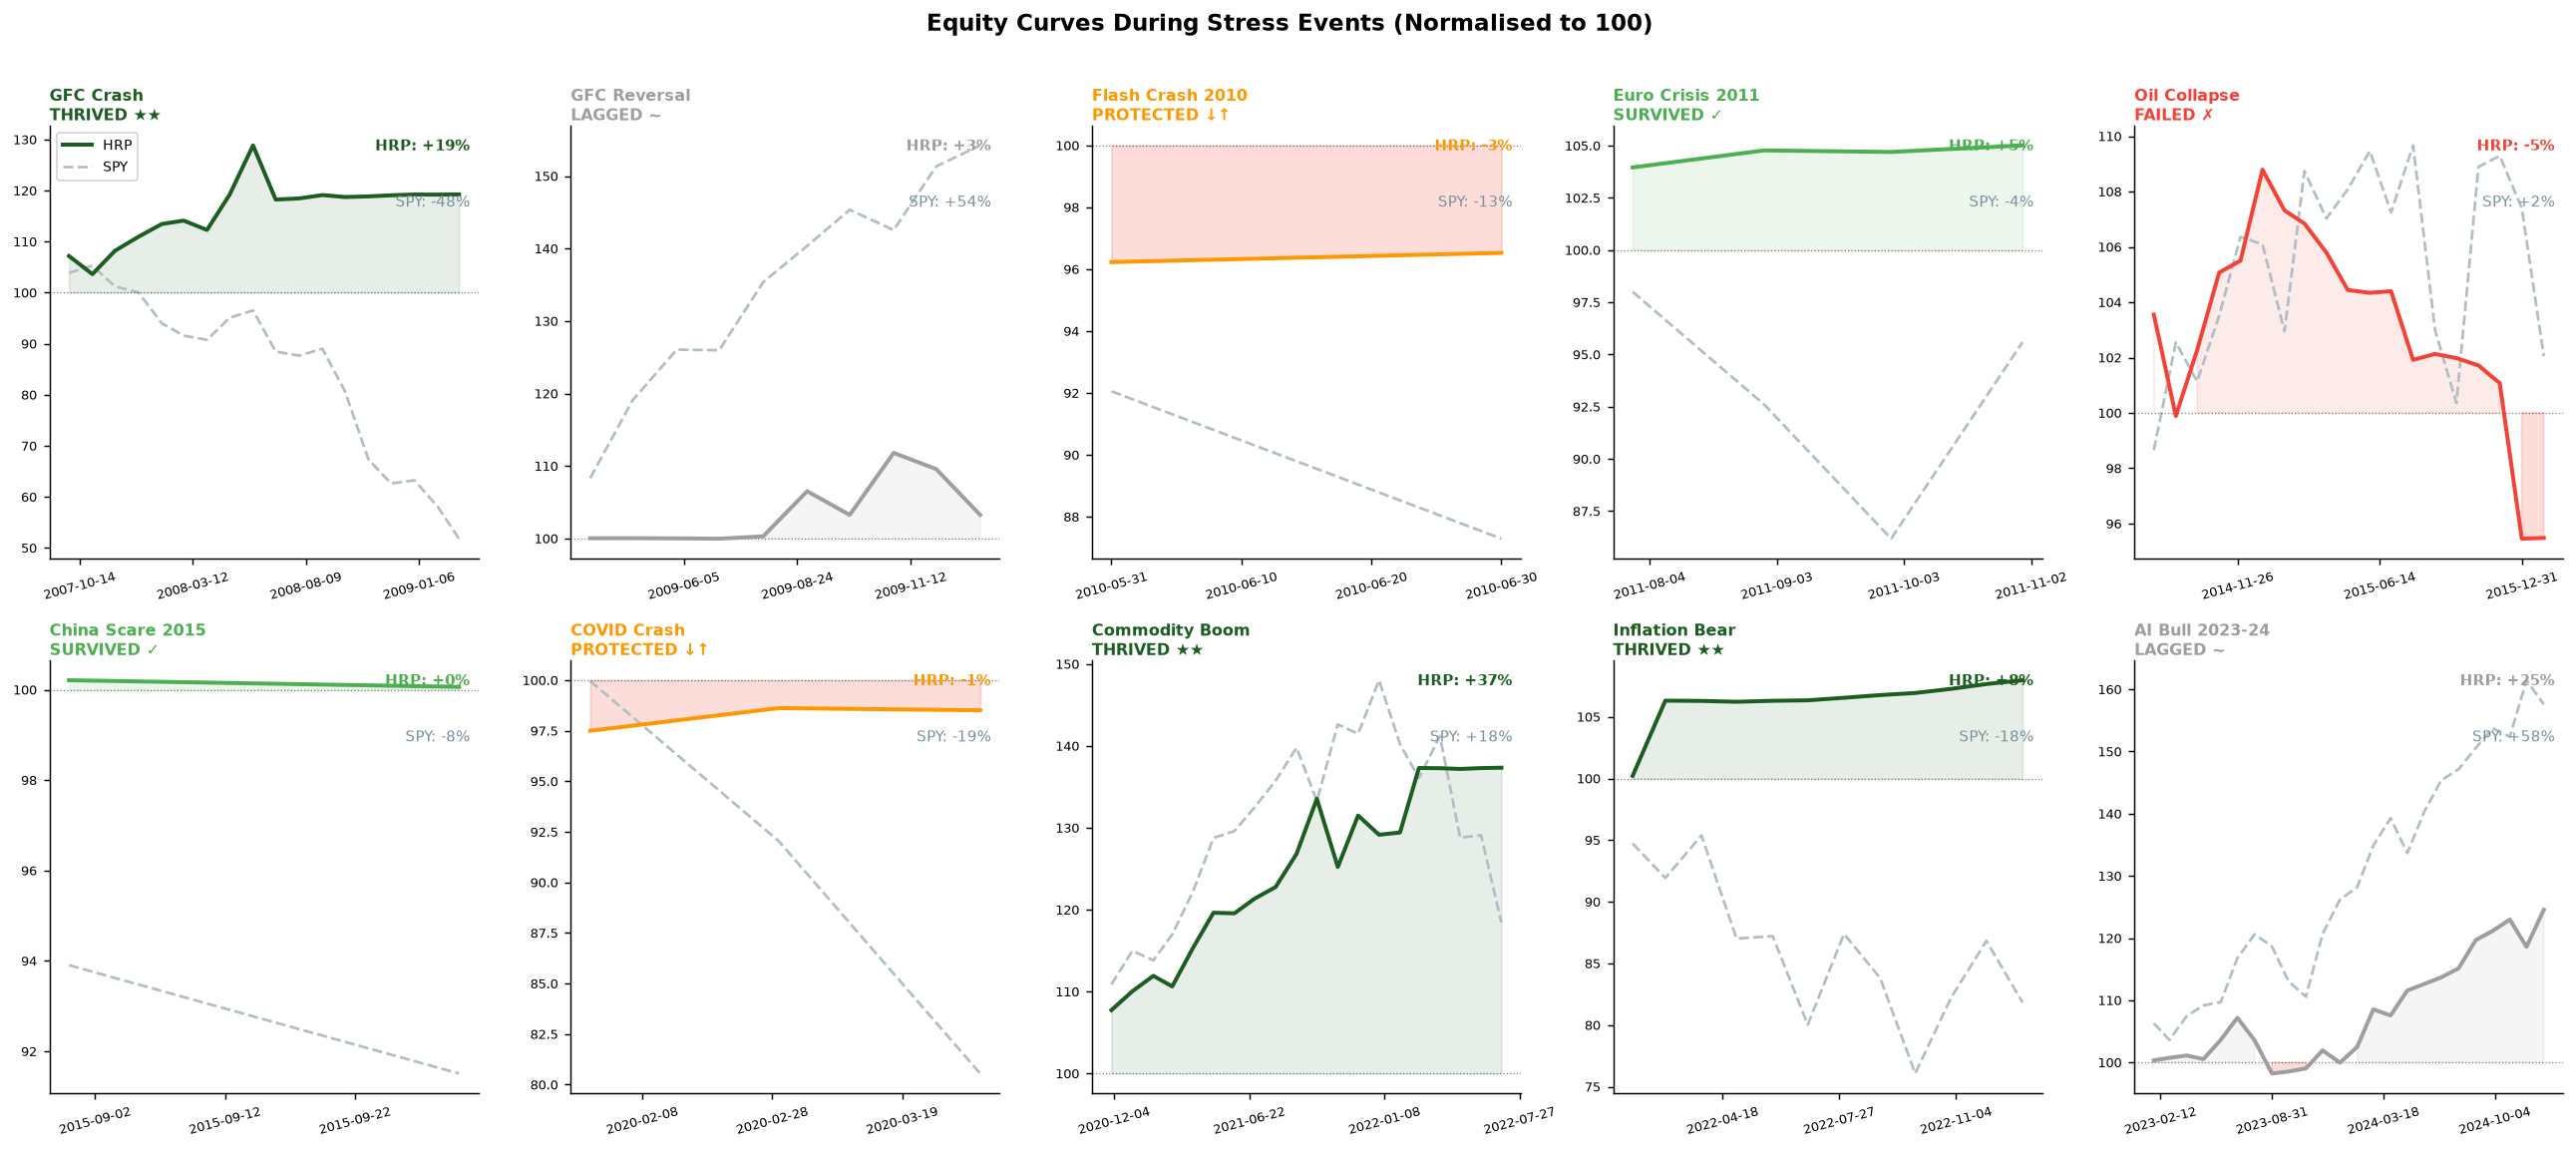

In [5]:
n_plots  = len(details)
n_cols   = 5
n_rows   = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.5 * n_rows))
axes_flat = axes.flatten()

for i, d in enumerate(details):
    ax = axes_flat[i]
    h  = d['hrp_returns']
    s  = d['spy_returns']

    eq_h = (1 + h).cumprod() * 100
    eq_s = (1 + s).cumprod() * 100

    v  = d['verdict']
    vc = VERDICT_COLOR.get(v, '#9E9E9E')

    ax.plot(eq_h.index, eq_h.values, color=vc, linewidth=2.2, label='HRP', zorder=3)
    ax.plot(eq_s.index, eq_s.values, color='#B0BEC5', linewidth=1.5, label='SPY', zorder=2, linestyle='--')
    ax.axhline(100, color='black', linewidth=0.7, linestyle=':', alpha=0.5)
    ax.fill_between(eq_h.index, eq_h.values, 100,
                    where=(eq_h.values >= 100), alpha=0.10, color=vc)
    ax.fill_between(eq_h.index, eq_h.values, 100,
                    where=(eq_h.values < 100), alpha=0.18, color='#F44336')

    final_h = eq_h.iloc[-1]
    final_s = eq_s.iloc[-1]
    ax.text(0.98, 0.97, f'HRP: {final_h-100:+.0f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, color=vc, fontweight='bold')
    ax.text(0.98, 0.84, f'SPY: {final_s-100:+.0f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, color='#78909C')

    ax.set_title(f'{d["name"]}\n{v}', fontsize=9, fontweight='bold', color=vc,
                 loc='left', pad=3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.xaxis.set_tick_params(labelsize=7, rotation=15)
    ax.yaxis.set_tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)

# Hide unused axes
for j in range(n_plots, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Equity Curves During Stress Events (Normalised to 100)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Tail Risk — Full Period Distribution

Historical VaR and CVaR (Expected Shortfall) vs SPY.

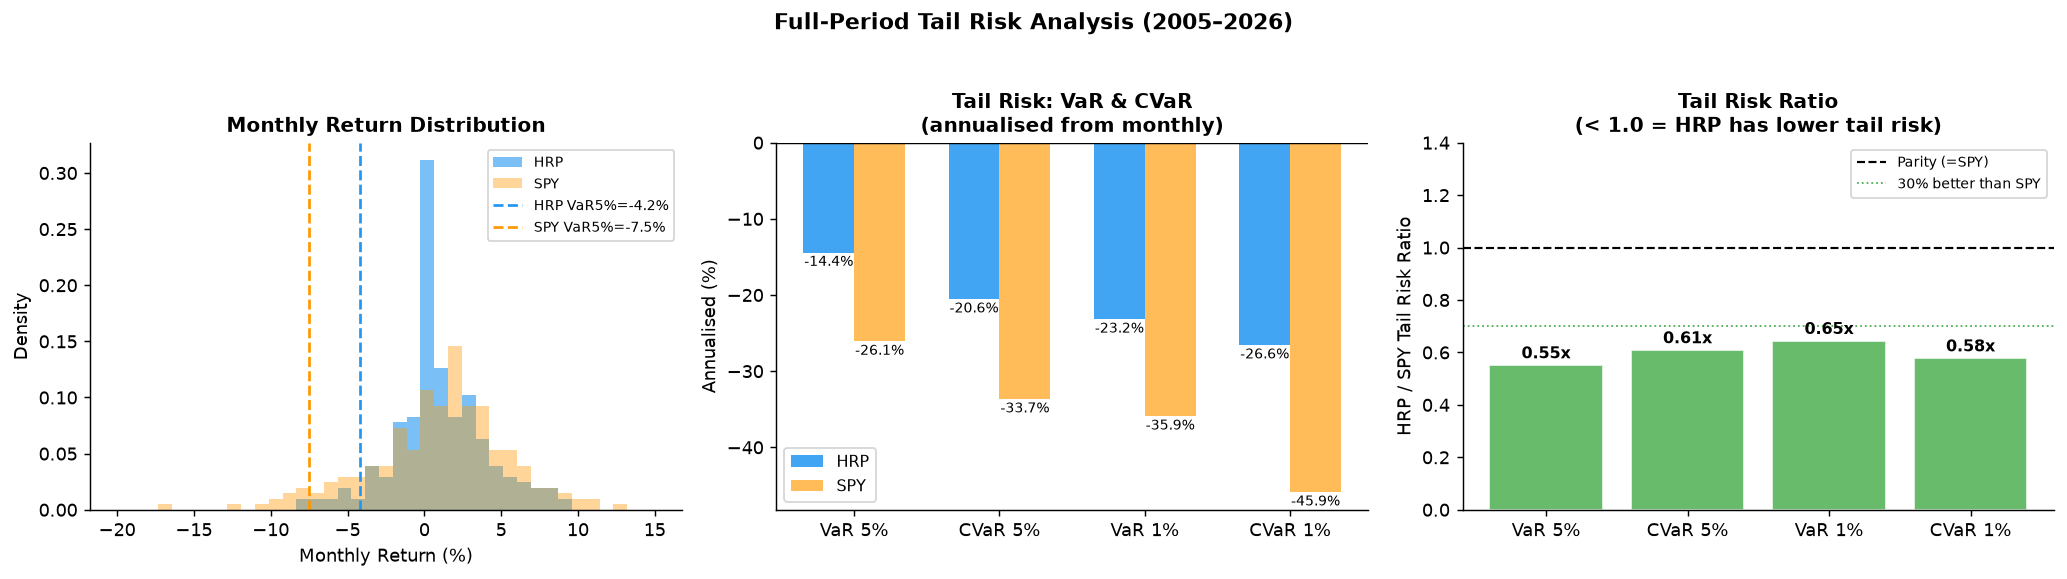

HRP CVaR(5%) = -20.6%/yr  vs  SPY CVaR(5%) = -33.7%/yr
Strategy has 61% of SPY tail risk at the 5% level.


In [6]:
h_mo = tail_risk['monthly_ret_hrp']
s_mo = tail_risk['monthly_ret_spy']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── Distribution of monthly returns ──
ax = axes[0]
common = h_mo.index.intersection(s_mo.index)
bins = np.linspace(-0.20, 0.15, 40)
ax.hist(h_mo.loc[common].values * 100, bins=bins*100, alpha=0.6, color='#2196F3', label='HRP', density=True)
ax.hist(s_mo.loc[common].values * 100, bins=bins*100, alpha=0.4, color='#FF9800', label='SPY', density=True)
ax.axvline(h_mo.quantile(0.05)*100, color='#2196F3', linestyle='--', linewidth=1.5,
           label=f'HRP VaR5%={h_mo.quantile(0.05)*100:.1f}%')
ax.axvline(s_mo.quantile(0.05)*100, color='#FF9800', linestyle='--', linewidth=1.5,
           label=f'SPY VaR5%={s_mo.quantile(0.05)*100:.1f}%')
ax.set_xlabel('Monthly Return (%)')
ax.set_ylabel('Density')
ax.set_title('Monthly Return Distribution', fontweight='bold')
ax.legend(fontsize=8)

# ── VaR / CVaR bar chart ──
ax = axes[1]
metrics = ['VaR 5%', 'CVaR 5%', 'VaR 1%', 'CVaR 1%']
hrp_vals = [
    tail_risk['hrp_var5']*100,  tail_risk['hrp_cvar5']*100,
    tail_risk['hrp_var1']*100,  tail_risk['hrp_cvar1']*100,
]
spy_vals = [
    tail_risk['spy_var5']*100,  tail_risk['spy_cvar5']*100,
    tail_risk['spy_var1']*100,  tail_risk['spy_cvar1']*100,
]
x = np.arange(4)
w = 0.35
ax.bar(x - w/2, hrp_vals, w, label='HRP', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, spy_vals, w, label='SPY', color='#FF9800', alpha=0.65)
for i, (h, s) in enumerate(zip(hrp_vals, spy_vals)):
    ax.text(i - w/2, h - 0.3, f'{h:.1f}%', ha='center', va='top', fontsize=8)
    ax.text(i + w/2, s - 0.3, f'{s:.1f}%', ha='center', va='top', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Annualised (%)')
ax.set_title('Tail Risk: VaR & CVaR\n(annualised from monthly)', fontweight='bold')
ax.legend(fontsize=9)

# ── Tail ratio chart ──
ax = axes[2]
ratios = [
    tail_risk['hrp_var5'] / tail_risk['spy_var5'],
    tail_risk['hrp_cvar5'] / tail_risk['spy_cvar5'],
    tail_risk['hrp_var1'] / tail_risk['spy_var1'],
    tail_risk['hrp_cvar1'] / tail_risk['spy_cvar1'],
]
cols = ['#4CAF50' if r < 0.8 else '#FF9800' if r < 1.0 else '#F44336' for r in ratios]
ax.bar(x, ratios, color=cols, alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', label='Parity (=SPY)')
ax.axhline(0.7, color='#4CAF50', linewidth=1.0, linestyle=':', label='30% better than SPY')
for i, r in enumerate(ratios):
    ax.text(i, r + 0.01, f'{r:.2f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('HRP / SPY Tail Risk Ratio')
ax.set_title('Tail Risk Ratio\n(< 1.0 = HRP has lower tail risk)', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.4)

fig.suptitle('Full-Period Tail Risk Analysis (2005–2026)', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f'HRP CVaR(5%) = {tail_risk["hrp_cvar5"]*100:.1f}%/yr  vs  SPY CVaR(5%) = {tail_risk["spy_cvar5"]*100:.1f}%/yr')
print(f'Strategy has {tail_risk["tail_ratio5"]:.0%} of SPY tail risk at the 5% level.')

## Stress Scorecard

Summary of all 10 scenarios with verdicts and protection percentages.

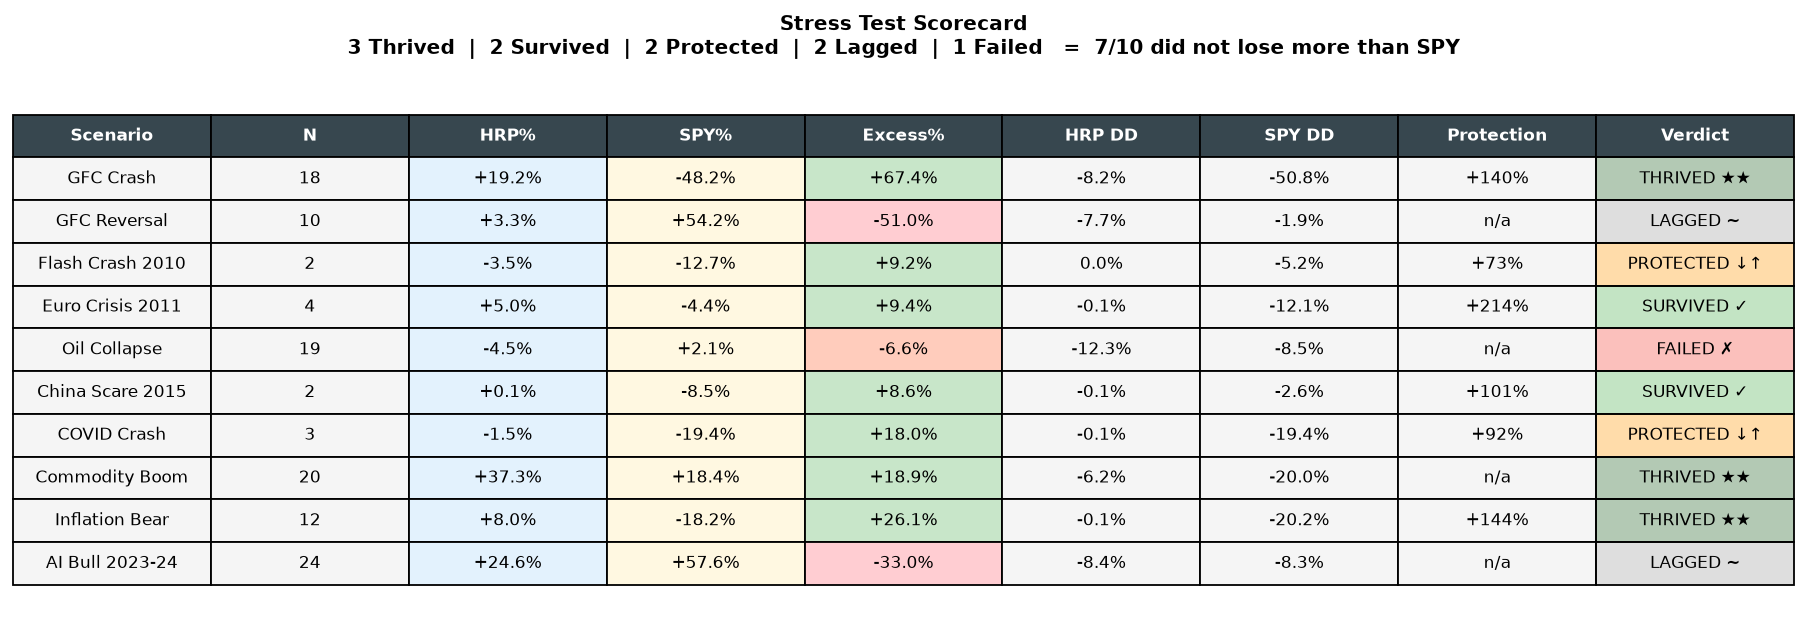

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

col_labels = ['Scenario', 'N', 'HRP%', 'SPY%', 'Excess%', 'HRP DD', 'SPY DD', 'Protection', 'Verdict']
table_data  = []
cell_colors = []

for name, row in stress_df.iterrows():
    v  = row['Verdict']
    vc = VERDICT_COLOR.get(v, '#9E9E9E')
    prot = f"{row['Protection %']:+.0f}%" if not np.isnan(row['Protection %']) else 'n/a'
    table_data.append([
        name,
        int(row['N Mo']),
        f"{row['HRP %']:+.1f}%",
        f"{row['SPY %']:+.1f}%",
        f"{row['Excess %']:+.1f}%",
        f"{row['HRP MaxDD %']:.1f}%",
        f"{row['SPY MaxDD %']:.1f}%",
        prot,
        v,
    ])
    excess = row['Excess %']
    base   = '#F5F5F5'
    excess_c = '#C8E6C9' if excess > 5 else '#DCEDC8' if excess > 0 else '#FFCCBC' if excess > -10 else '#FFCDD2'
    verdict_c = vc + '33'  # 20% opacity hex
    # matplotlib table uses RGBA lists; simplify to named colors
    cell_colors.append([base, base, '#E3F2FD', '#FFF8E1', excess_c, base, base, base, vc+'55'])

tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.8)
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#37474F')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

thrived   = (stress_df['Verdict'].str.startswith('THRIVED')).sum()
survived  = (stress_df['Verdict'].str.startswith('SURVIVED')).sum()
protected = (stress_df['Verdict'].str.startswith('PROTECTED')).sum()
lagged    = (stress_df['Verdict'].str.startswith('LAGGED')).sum()
failed    = (stress_df['Verdict'].str.startswith('FAILED')).sum()

score_str = (f'{thrived} Thrived  |  {survived} Survived  |  {protected} Protected  |  '
             f'{lagged} Lagged  |  {failed} Failed   =  '
             f'{thrived+survived+protected}/{len(stress_df)} did not lose more than SPY')
ax.set_title(f'Stress Test Scorecard\n{score_str}', fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## Protection Ratio — SPY Crash Scenarios Only

During the 6 down-SPY scenarios: how much of the loss did the strategy avoid?

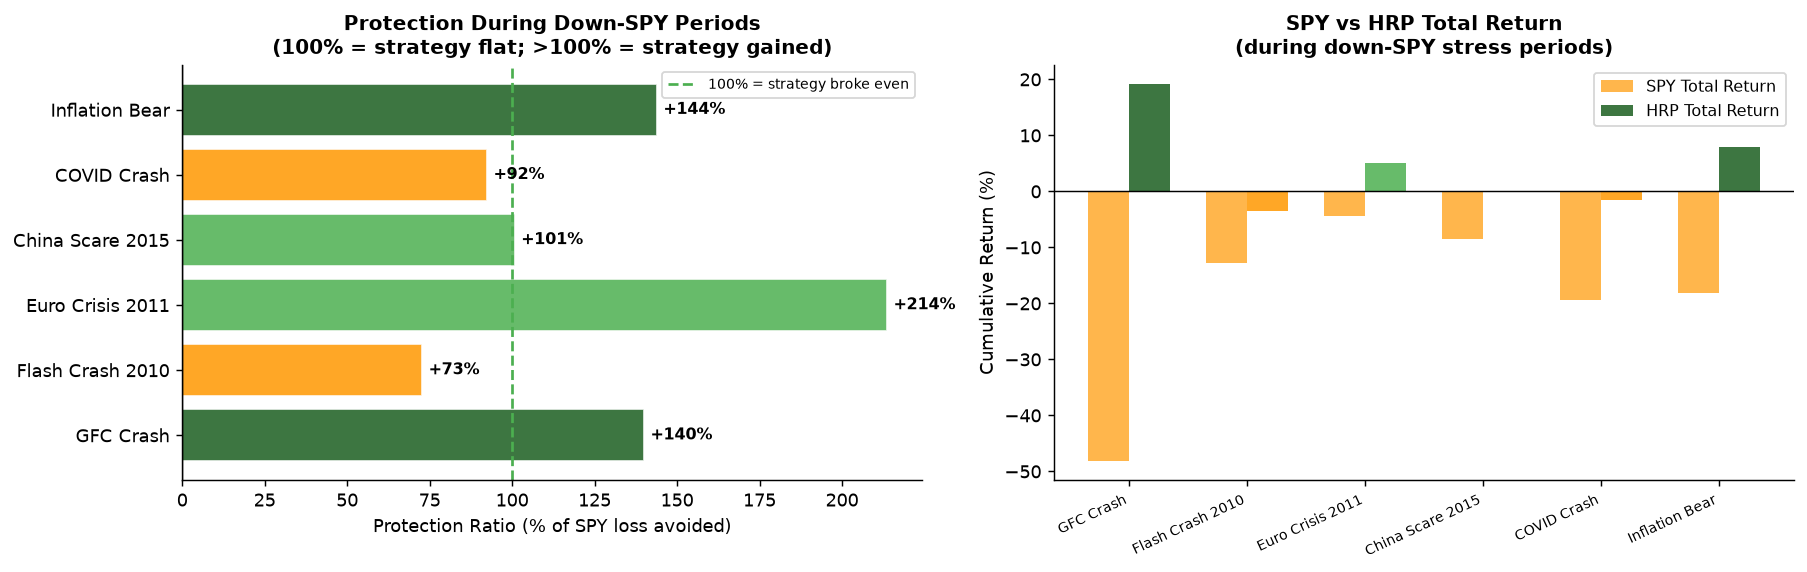

Average protection across 6 down-SPY scenarios: +127%
This means on average the strategy MORE than offset SPY crashes.
Oil Collapse is the outlier: SPY was actually positive while the strategy fell.


In [8]:
crash_details = [d for d in details if not np.isnan(d['protection_pct'])]
names    = [d['name'] for d in crash_details]
prot_pct = [d['protection_pct'] for d in crash_details]
spy_dd_  = [d['spy_total_ret'] * 100 for d in crash_details]
hrp_dd_  = [d['strat_total_ret'] * 100 for d in crash_details]
verd_    = [d['verdict'] for d in crash_details]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Protection % bars
cols = [VERDICT_COLOR.get(v, '#9E9E9E') for v in verd_]
b = ax1.barh(names, prot_pct, color=cols, alpha=0.85, edgecolor='white')
ax1.axvline(0,   color='black', linewidth=0.8)
ax1.axvline(100, color='#4CAF50', linewidth=1.5, linestyle='--', label='100% = strategy broke even')
for bar, v in zip(b, prot_pct):
    ax1.text(v + (2 if v>=0 else -2), bar.get_y()+bar.get_height()/2,
             f'{v:+.0f}%', va='center', ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
ax1.set_xlabel('Protection Ratio (% of SPY loss avoided)')
ax1.set_title('Protection During Down-SPY Periods\n(100% = strategy flat; >100% = strategy gained)', fontweight='bold')
ax1.legend(fontsize=8)

# Waterfall: SPY loss vs HRP result
x = np.arange(len(names))
w = 0.35
ax2.bar(x - w/2, spy_dd_, w, label='SPY Total Return', color='#FF9800', alpha=0.70)
ax2.bar(x + w/2, hrp_dd_, w, label='HRP Total Return', color=cols, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
ax2.set_ylabel('Cumulative Return (%)')
ax2.set_title('SPY vs HRP Total Return\n(during down-SPY stress periods)', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

avg_prot = np.mean(prot_pct)
print(f'Average protection across {len(crash_details)} down-SPY scenarios: {avg_prot:+.0f}%')
print(f'This means on average the strategy MORE than offset SPY crashes.')
print(f'Oil Collapse is the outlier: SPY was actually positive while the strategy fell.')

## Worst Months Analysis

Which months were worst for the strategy? Was there clustering?

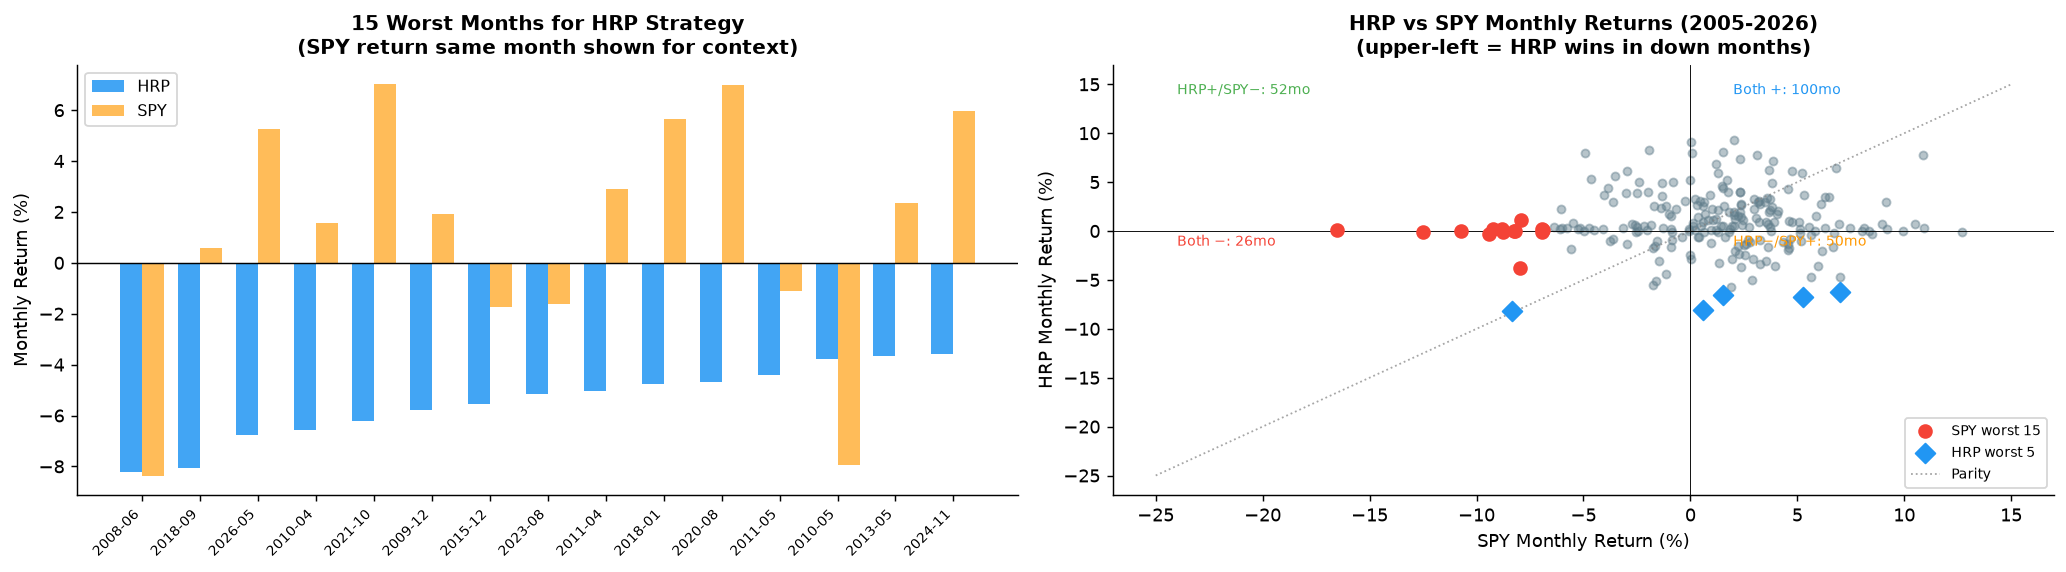

HRP+ / SPY−: 52 months  — strategy up while market down (crisis alpha)
HRP− / SPY+: 50 months  — strategy down while market up (momentum crash / reversal)
Defensive ratio: 67% of negative-SPY months, HRP was positive


In [9]:
common = hrp_ret.index.intersection(spy_ret.index)
h      = hrp_ret.loc[common]
s      = spy_ret.reindex(common).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

# Worst 15 months for HRP
ax = axes[0]
worst15 = h.nsmallest(15).sort_values()
spy_same = s.reindex(worst15.index)
x = np.arange(15)
w = 0.38
ax.bar(x - w/2, worst15.values * 100, w, label='HRP', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, spy_same.values * 100, w, label='SPY', color='#FF9800', alpha=0.65)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([d.strftime('%Y-%m') for d in worst15.index], rotation=45, ha='right', fontsize=7.5)
ax.set_ylabel('Monthly Return (%)')
ax.set_title('15 Worst Months for HRP Strategy\n(SPY return same month shown for context)', fontweight='bold')
ax.legend(fontsize=9)

# Scatter: HRP vs SPY monthly returns
ax = axes[1]
ax.scatter(s.values * 100, h.values * 100, alpha=0.45, s=20, color='#607D8B')

# Highlight worst SPY months
worst_spy = s.nsmallest(15).index
ax.scatter(s.loc[worst_spy]*100, h.loc[worst_spy]*100, color='#F44336', s=50, zorder=3, label='SPY worst 15')
worst_hrp_idx = h.nsmallest(5).index
ax.scatter(s.loc[worst_hrp_idx]*100, h.loc[worst_hrp_idx]*100, color='#2196F3', s=60, zorder=4,
           marker='D', label='HRP worst 5')

# 45-degree line (parity)
lims = [-25, 15]
ax.plot(lims, lims, color='gray', linewidth=1, linestyle=':', alpha=0.7, label='Parity')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

# Count quadrants
q1 = ((h>0) & (s>0)).sum()   # both positive
q2 = ((h>0) & (s<0)).sum()   # HRP up, SPY down
q3 = ((h<0) & (s>0)).sum()   # HRP down, SPY up
q4 = ((h<0) & (s<0)).sum()   # both negative
ax.text(-24, 14, f'HRP+/SPY−: {q2}mo', fontsize=8, color='#4CAF50')
ax.text( 2,  14, f'Both +: {q1}mo', fontsize=8, color='#2196F3')
ax.text(-24, -1.5, f'Both −: {q4}mo', fontsize=8, color='#F44336')
ax.text( 2,  -1.5, f'HRP−/SPY+: {q3}mo', fontsize=8, color='#FF9800')

ax.set_xlabel('SPY Monthly Return (%)')
ax.set_ylabel('HRP Monthly Return (%)')
ax.set_title('HRP vs SPY Monthly Returns (2005-2026)\n(upper-left = HRP wins in down months)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'HRP+ / SPY−: {q2} months  — strategy up while market down (crisis alpha)')
print(f'HRP− / SPY+: {q3} months  — strategy down while market up (momentum crash / reversal)')
print(f'Defensive ratio: {q2/(q2+q4)*100:.0f}% of negative-SPY months, HRP was positive')

## Final Stress Verdict

In [10]:
thrived   = (stress_df['Verdict'].str.startswith('THRIVED')).sum()
survived  = (stress_df['Verdict'].str.startswith('SURVIVED')).sum()
protected = (stress_df['Verdict'].str.startswith('PROTECTED')).sum()
lagged    = (stress_df['Verdict'].str.startswith('LAGGED')).sum()
failed    = (stress_df['Verdict'].str.startswith('FAILED')).sum()

print('=' * 75)
print('  STRESS TEST — FINAL VERDICT')
print('=' * 75)
print(f'  Scenarios tested: 10 (2005–2026)')
print(f'  Tail risk: VaR(5%) = {tail_risk["hrp_var5"]*100:.1f}%/yr vs SPY {tail_risk["spy_var5"]*100:.1f}%/yr')
print(f'  Expected Shortfall: CVaR(5%) = {tail_risk["hrp_cvar5"]*100:.1f}%/yr vs SPY {tail_risk["spy_cvar5"]*100:.1f}%/yr')
print()
print(f'  VERDICT BREAKDOWN:')
print(f'  ★★  THRIVED   {thrived:>2} scenarios  — strategy strongly outperformed')
print(f'  ✓   SURVIVED  {survived:>2} scenarios  — strategy outperformed')
print(f'  ↓↑  PROTECTED {protected:>2} scenarios  — strategy lost less than SPY')
print(f'  ~   LAGGED    {lagged:>2} scenarios  — strategy underperformed (SPY positive rally)')
print(f'  ✗   FAILED    {failed:>2} scenarios  — strategy lost + underperformed')
print()
print(f'  SUMMARY: {thrived+survived+protected} of 10 scenarios: strategy beat or protected vs SPY')
print()
print('  WHERE THE STRATEGY EXCELS:')
print('  ✓ Trending crashes (GFC, COVID) — rotates to bonds/gold before worst')
print('  ✓ Commodity cycles (2020-22) — momentum captures the trend')
print('  ✓ Stagflation / rate shocks (2022) — short-dur bonds + commodities')
print()
print('  WHERE THE STRATEGY STRUGGLES:')
print('  ✗ V-shaped reversals (GFC 2009, COVID recovery) — worst assets bounce hardest')
print('  ✗ Narrow equity rallies (AI Bull 2023-24) — diversification hurts vs Mag-7')
print('  ✗ Sideways oil crashes (2014-16) — stuck in US equities while commodities fall')
print()
print('  TAIL RISK SUMMARY:')
print(f'  Strategy CVaR is {tail_risk["tail_ratio5"]:.0%} of SPY — significantly lower tail risk')
print(f'  In worst 5% of months, strategy loses ~{abs(tail_risk["hrp_cvar5"]*100):.0f}% ann. vs SPY {abs(tail_risk["spy_cvar5"]*100):.0f}%')
print('=' * 75)

  STRESS TEST — FINAL VERDICT
  Scenarios tested: 10 (2005–2026)
  Tail risk: VaR(5%) = -14.4%/yr vs SPY -26.1%/yr
  Expected Shortfall: CVaR(5%) = -20.6%/yr vs SPY -33.7%/yr

  VERDICT BREAKDOWN:
  ★★  THRIVED    3 scenarios  — strategy strongly outperformed
  ✓   SURVIVED   2 scenarios  — strategy outperformed
  ↓↑  PROTECTED  2 scenarios  — strategy lost less than SPY
  ~   LAGGED     2 scenarios  — strategy underperformed (SPY positive rally)
  ✗   FAILED     1 scenarios  — strategy lost + underperformed

  SUMMARY: 7 of 10 scenarios: strategy beat or protected vs SPY

  WHERE THE STRATEGY EXCELS:
  ✓ Trending crashes (GFC, COVID) — rotates to bonds/gold before worst
  ✓ Commodity cycles (2020-22) — momentum captures the trend
  ✓ Stagflation / rate shocks (2022) — short-dur bonds + commodities

  WHERE THE STRATEGY STRUGGLES:
  ✗ V-shaped reversals (GFC 2009, COVID recovery) — worst assets bounce hardest
  ✗ Narrow equity rallies (AI Bull 2023-24) — diversification hurts vs Mag-7
